In [1]:
using StatsBase, Distributions, SharedArrays, Random
Random.seed!(741234)
# Input parameters
# ------------------------------------------------

const BURN_IN_GEN_N = 0
const TOTAL_GEN_N = 4

# Max coordinates of the population bounding space
# (population = disk)
const R_MAX_BURN_IN = 3
const R_MAX = 100

const X_MAX = R_MAX
const Y_MAX = R_MAX
const X_START = R_MAX_BURN_IN
const Y_START = R_MAX_BURN_IN

# Dimensions of the whole space
const X_DIM = 2*X_MAX+1
const Y_DIM = 2*Y_MAX+1

# Population parameters
#const INIT_PERSON_N = 30
const DEMES_FULL_AT_START = 5
const K_CAPACITY = 100
const R_PROLIF_RATE = 2
const r_LOG_PROLIF_RATE = log(2)

# Gene parameters
const LOCI_N = 20
const MUT_RATE = 0.1
const M_MIG_RATE = 0.05
const MUT_DELETER_RATE = 0.9
const S_SELECT_COEF = 0.005
const possible_dirs = [[-1,0],[0,-1],[0,1],[1,0]] #[[-1,-1],[-1,0],[-1,1],[0,-1],[0,1],[1,-1],[1,0],[1,1]]

# Main program
# ------------------------------------------------

x_range = (X_MAX+1-X_START):(X_MAX+1+X_START)
y_range = (Y_MAX+1-Y_START):(Y_MAX+1+Y_START)
possible_init_coords = [collect(x) for x in Iterators.product(x_range, y_range)]
init_coords = sample(possible_init_coords,DEMES_FULL_AT_START;replace=false)

world = Array{Array{Array{Float32}}}(undef,X_DIM,Y_DIM)

for coord in init_coords
    if !isassigned(world,coord...)
        world[coord...] = []
    end
    for i in 1:K_CAPACITY
        push!(world[coord...],ones(LOCI_N*2))
    end
end

a = SharedArray{Float32}(X_MAX, Y_MAX, TOTAL_GEN_N, 1)
a = SharedArray{Float32}(X_MAX, Y_MAX, TOTAL_GEN_N, 1)

@inbounds function multi_fitn_in_person(person)
    return prod(person)
end

@inbounds function max_fitn(persons_at_pos)
    return maximum(multi_fitn_in_person.(persons_at_pos))
end

@inbounds function mean_fitn(persons_at_pos)
    return mean(multi_fitn_in_person.(persons_at_pos))
end

@inbounds function mutate(person)
    get_mutation_random = rand(Poisson(MUT_RATE))
    @fastmath @inbounds for _ in 1:get_mutation_random
        pos_alter = sample(1:LOCI_N)
        if rand() < MUT_DELETER_RATE
            person[pos_alter] *= 1 - S_SELECT_COEF
        else
            person[pos_alter] *= 1 + S_SELECT_COEF
        end
    end
end

@inbounds function recombine(person)
    for i in 1:LOCI_N
        lr = rand(1:2)
        person[i] = lr==1 ? person[i] : person[i+LOCI_N]
    end
end

@inbounds function mate_cond(mom_fit,dad_fit,max_fitness)
    return (mom_fit > rand()*max_fitness) & (dad_fit > rand()*max_fitness)
end

@inbounds function mate(person1,person2)
    new_loci = vcat(person1[1:LOCI_N],person2[1:LOCI_N])
    return new_loci
end

@inbounds function build_next_gen(wld,r_max_migrate)
    # Determine the number of offspring for each deme
    next_gen_pops = zeros(Int16,X_DIM,Y_DIM)
    next_gen_posits = []
    
    fill!(next_gen_pops,-1)
    for k in Iterators.product([1:n for n in (X_DIM,Y_DIM)]...)
        if isassigned(world,k...) && length(world[k...])>0
            n_ppl_at_deme = length(world[k...])
            expected_offspring = n_ppl_at_deme * (R_PROLIF_RATE/(1 + (n_ppl_at_deme*(R_PROLIF_RATE-1))/K_CAPACITY))
            #println("A",n_ppl_at_deme)
            next_gen_pops[k...] =  rand(Poisson(expected_offspring))
            if next_gen_pops[k...]>0
                push!(next_gen_posits,[k...])
            end
            #println("B",next_gen_pops[k...],next_gen_posits)
        end
    end
    

    # Define the world (habitat)
    wld_next = Array{Array{Array{Float32}}}(undef,X_DIM,Y_DIM)
    
    all_birth_count = 0

    # Main generation cycle (algorithm)
    mean_fitn_wld = Array{Float32}(undef,X_DIM,Y_DIM)
    fill!(mean_fitn_wld,-1)
    pops_wld = zeros(Int32,X_DIM,Y_DIM)

    for deme in next_gen_posits
        curr_persons_at_pos = wld[deme...]
        mean_fitn_wld[deme...] = mean_fitn(curr_persons_at_pos)
        max_fitness =  max_fitn(curr_persons_at_pos)
        

        next_generation_size = next_gen_pops[deme...]
        
        if next_generation_size > 0
            birth_count = 0
            
            while birth_count < next_generation_size
                
                mom = sample(curr_persons_at_pos) #[rand(1:end)]
                dad = sample(curr_persons_at_pos) #[rand(1:end)]
                
                mom_fit = multi_fitn_in_person(mom)
                dad_fit = multi_fitn_in_person(dad)

                if mate_cond(mom_fit,dad_fit,max_fitness)
                    
                    gamete_mom = copy(mom) # technically a person, but we'll only use the first half of loci in the mate function
                    gamete_dad = copy(dad) # technically a person, but we'll only use the first half of loci in the mate function
                    recombine(gamete_mom)
                    recombine(gamete_dad)
                    mutate(gamete_mom)
                    mutate(gamete_dad)
                    println(rand())
                    mate_result = mate(gamete_mom,gamete_dad)
                    
                    #mutate(mate_result)

                    res_x = copy(deme[1])
                    res_y = copy(deme[2])
                    
                    if rand()<M_MIG_RATE
                        
                        dir = copy(sample(possible_dirs))
                        move_x = copy(dir[1])
                        move_y = copy(dir[2])

                        x2 = (deme[1]-X_MAX-1+move_x)*(deme[1]-X_MAX-1+move_x)
                        y2 = (deme[2]-Y_MAX-1+move_y)*(deme[2]-Y_MAX-1+move_y)
                        r2 = x2+y2
                        
                        if r2 > r_max_migrate*r_max_migrate
                            res_x = X_MAX+1-trunc(Int16,(r_max_migrate*r_max_migrate/r2) * move_x)
                            res_y = Y_MAX+1-trunc(Int16,(r_max_migrate*r_max_migrate/r2) * move_y)
                        else
                            res_x += move_x
                            res_y += move_y
                        end
                    end

                    if !isassigned(wld_next,res_x,res_y)
                        wld_next[res_x,res_y] = []
                    end
                    push!(wld_next[res_x,res_y],mate_result)
                    #println([move_x,move_y],deme)
                    birth_count += 1
                    all_birth_count += 1
                end
            end
            pops_wld[deme...] = birth_count
        end
    end
    return wld_next,mean_fitn_wld,pops_wld
end

# Iterate the main cycle and save the output
# ------------------------------------------------

meanf_world = Array{Float32}(undef,X_DIM,Y_DIM,0)
pops_world = Array{Float32}(undef,X_DIM,Y_DIM,0)

@inbounds for _ in 1:BURN_IN_GEN_N
    global world,meanf,pops = build_next_gen(world,R_MAX_BURN_IN)
    global meanf_world = cat(meanf_world,meanf, dims=3)
    global pops_world = cat(pops_world,pops, dims=3)
end

@inbounds for _ in (BURN_IN_GEN_N+1):TOTAL_GEN_N
    println(3)
    global world,meanf,pops = build_next_gen(world,R_MAX)
    global meanf_world = cat(meanf_world,meanf, dims=3)
    global pops_world = cat(pops_world,pops, dims=3)
end

3
0.13227200415132434
0.44255813473044037
0.6621572232730055
0.5439084844884171
0.6603270385623952
0.21662743707835308
0.8960523351619759
0.8337764978040415
0.0382499572412518
0.9530624049330573
0.3360700135014182
0.9768397531662034
0.9197248041459
0.7022490858620593
0.525245545097036
0.9708203635161666
0.3219326099173093
0.3281295342690086
0.9064011121349919
0.09035277560487442
0.5398774912768699
0.5768713627802806
0.7494117365699495
0.6167077143453971
0.013372106552820284
0.702870914547465
0.40094823533076807
0.885242600205136
0.9675934710300399
0.0976753853932052
0.8341945022391526
0.1378786108848744
0.3149130665996106
0.2678875670442775
0.3081567086215755
0.0717294549205666
0.21780243198291205
0.8068256089765504
0.08815729048237608
0.7247966992437104
0.9485832025665814
0.35904717623817617
0.7225510728849956
0.8771549071260275
0.23358088320200954
0.9411095483986194
0.6419129071784336
0.7542628132091302
0.7764265987536823
0.17890872815161551
0.33055159664437317
0.2020908520478688
0.9

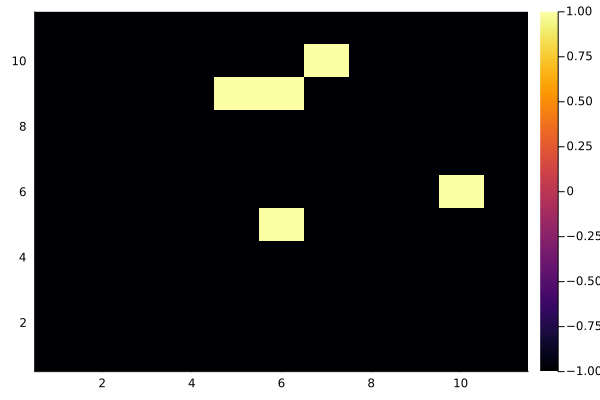

In [9]:
using Plots
heatmap(meanf_world[95:105,95:105,1])

In [2]:
meanf_world[95:105,95:105,2]

11×11 Matrix{Float32}:
 -1.0  -1.0  -1.0  -1.0  -1.0  …  -1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0      1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  …   0.999369   1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0      1.0        1.0      0.999175   1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0        0.9975   0.999087   1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0       -1.0      0.996675  -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0     -1.0       -1.0     -1.0       -1.0
 -1.0  -1.0  -1.0  -1.0  -1.0  …  -1.0       -1.0     -1.0       -1.0

In [2]:
using Serialization
serialize("data/heh/2d_test_10-meanf.dat",meanf_world)

1200000

┌ Info: Saved animation to d:\Coding\RESK\study\animations\3-1.gif
└ @ Plots C:\Users\Hartree\.julia\packages\Plots\ju9dp\src\animation.jl:156


Plots.AnimatedGif("d:\\Coding\\RESK\\study\\animations\\3-1.gif")
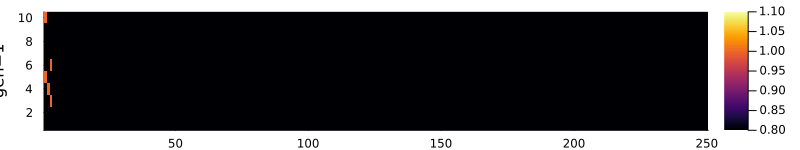

In [12]:
using Plots
slow_down = 1
gen_start = 1
gen_end = 60

anim = @animate for i ∈ gen_start:(gen_end-1)
    heatmap(meanf_world[:,:,i]',ylabel="gen=$i",size=(800,150),clims=(0.8,1.1))
end
gif(anim,"animations/3-1.gif")

In [9]:
f(x) = [i^23/5455 for i in 1:x]
a, timte = @timed f(33333)
println(timte)

0.0002342


In [72]:
MIGR_PROBS = [
    Dict(["ort" => (1, 0)]), # 1D
    Dict(["ort" => (1, 0), "all" => (1 / 2, 1 / 2), "buffon1" => (2 / pi, 1 / pi), "buffon2" => (4 / 3 / pi, 1 / 3 / pi), "buffon3" => (0.4244132, 0.21221), "diag1/2" => (2 / 3, 1 / 3)]), # 2D. To add "hex"!
    Dict(["ort" => (1, 0), "all" => (1 / 2, 1 / 2), "buffon1" => (2 / pi, 1 / pi), "buffon2" => (4 / 3 / pi, 1 / 3 / pi), "buffon3" => (0.4244132, 0.21221), "diag1/2" => (2 / 3, 1 / 3)]) # 3D. To add "hex"! To confirm Buffon for 3d!
]
MIGR_DIRS_ORT = [
    [[1], [-1]], # 1D
    [[-1, 0], [0, -1], [0, 1], [1, 0]], # 2D
    [[-1, 0, 0], [1, 0, 0], [0, 1, 0], [0, -1, 0], [0, 0, -1], [0, 0, 1]] # 3D
]

meow1 = []
Random.seed!(3333)
for _ in 1:80000
    
    migr_res = 0.5
    p_lat, p_diag = MIGR_PROBS[1]["ort"]

    if rand() < M_MIG_RATE && migr_res < p_lat + p_diag
        if migr_res < p_lat
            dir = copy(sample(MIGR_DIRS_ORT[1]))
        elseif migr_res < p_lat + p_diag
            dir = copy(sample(MIGR_DIRS_DIAG[1]))
        end
        meow1 = vcat(meow1,dir)
    end
end
meow2 = []
Random.seed!(3333)
for _ in 1:80000
    if rand() < M_MIG_RATE
        move_x = sample([1,-1])
        meow2 = vcat(meow2,move_x)
    end
end

In [74]:
meow2

3873-element Vector{Any}:
  1
  1
 -1
 -1
  1
 -1
  1
 -1
 -1
  1
  ⋮
  1
 -1
  1
 -1
 -1
  1
 -1
 -1
  1